<a href="https://colab.research.google.com/github/adishup/gen-ai-lab/blob/main/experiment%209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q diffusers transformers accelerate safetensors

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


EXPERIMENT 9 - IMAGE GENERATION

GPU Available:
Tesla T4

Loading Stable Diffusion model...
This may take some time on the first run.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Stable Diffusion model loaded successfully.

IMAGE PROMPT

Enter your image prompt: A futuristic smart city with flying cars, green buildings, robots assisting people, highly detailed

Generating image...
Please wait...


  0%|          | 0/25 [00:00<?, ?it/s]


Image generated successfully.


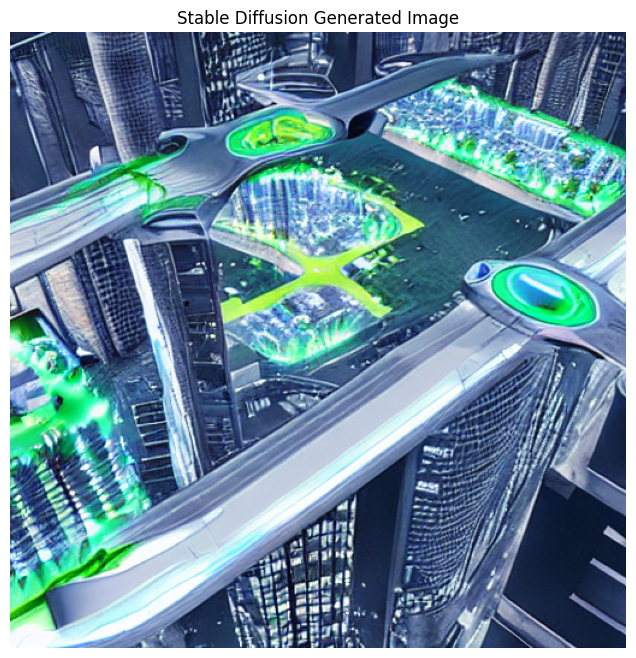


IMAGE GENERATION RESULT
Prompt:
A futuristic smart city with flying cars, green buildings, robots assisting people, highly detailed

Saved file:
generated_image.png

EXPERIMENT 9 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# EXPERIMENT 9
# IMAGE GENERATION USING STABLE DIFFUSION
# ============================================================

import torch
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline


print("=" * 60)
print("EXPERIMENT 9 - IMAGE GENERATION")
print("=" * 60)


# ============================================================
# 1. CHECK GPU
# ============================================================

if torch.cuda.is_available():

    device = "cuda"

    print("\nGPU Available:")
    print(torch.cuda.get_device_name(0))

else:

    device = "cpu"

    print("\nGPU not available.")
    print("Using CPU - image generation will be slower.")


# ============================================================
# 2. LOAD STABLE DIFFUSION MODEL
# ============================================================

model_id = "runwayml/stable-diffusion-v1-5"

print("\nLoading Stable Diffusion model...")
print("This may take some time on the first run.")


if device == "cuda":

    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        safety_checker=None
    )

else:

    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float32,
        safety_checker=None
    )


# Move model to GPU/CPU

pipe = pipe.to(device)


# Memory optimization for Colab

if device == "cuda":

    pipe.enable_attention_slicing()


print("\nStable Diffusion model loaded successfully.")


# ============================================================
# 3. ENTER PROMPT
# ============================================================

print("\n" + "=" * 60)
print("IMAGE PROMPT")
print("=" * 60)

prompt = input(
    "\nEnter your image prompt: "
)


# ============================================================
# 4. GENERATE IMAGE
# ============================================================

print("\nGenerating image...")
print("Please wait...")


with torch.inference_mode():

    result = pipe(
        prompt=prompt,
        num_inference_steps=25,
        guidance_scale=7.5,
        height=512,
        width=512
    )


image = result.images[0]


# ============================================================
# 5. SAVE IMAGE
# ============================================================

output_file = "generated_image.png"

image.save(
    output_file
)


# ============================================================
# 6. DISPLAY IMAGE
# ============================================================

print("\nImage generated successfully.")

plt.figure(
    figsize=(8, 8)
)

plt.imshow(image)

plt.axis("off")

plt.title(
    "Stable Diffusion Generated Image"
)

plt.show()


# ============================================================
# 7. DISPLAY DETAILS
# ============================================================

print("\n" + "=" * 60)
print("IMAGE GENERATION RESULT")
print("=" * 60)

print("Prompt:")
print(prompt)

print("\nSaved file:")
print(output_file)


# ============================================================
# 8. COMPLETION
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT 9 COMPLETED SUCCESSFULLY")
print("=" * 60)